In [256]:
import pandas as pd
df = pd.read_csv("AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


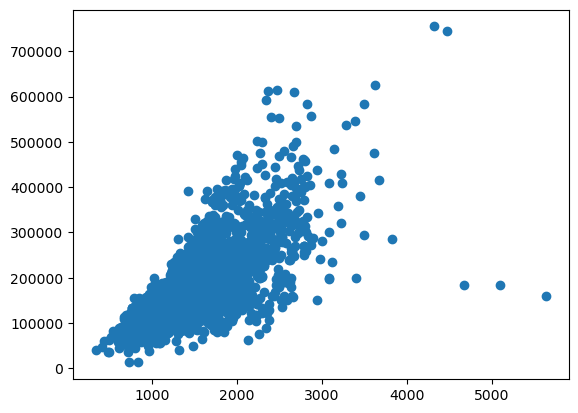

In [257]:
import matplotlib.pyplot as plt

x = df["Gr Liv Area"]
y = df["SalePrice"]

plt.scatter(x,y)
plt.show()

# Correlation

- Correlation $r$
  - - $r$ in [-1.0, 1.0]
  - 1.0 mean perfect positive linear correlation (as x increase, so does y; as x decreases, so does y)
  -  -1.0 mean perfect inverse linear correlation (as x increases, y decreases; as x decreases, y increases)
-  Correlation does not imply causation


In [258]:
import scipy.stats as stats

r, pval = stats.pearsonr(x,y)
print(f"r: {r}, pval: {pval}")

r: 0.7067799209766279, pval: 0.0


# Intro to Regression
- Recall: if the class we want to predict is numeric -> regression
- There are a few regression algorithms
  - Linear Regression 
  - kNN Regressor
  - Decision Tree Regression
  - Etc.
- Goal: to fit a line to our x,y data so we use the linear model to make sales price predictions for unseen homes (similar to zillow Zestimate)
  - Recall: y = mx + b
    - m = slope
    - b = intercept
  - if we can find m and b for our x,y data, then we can make predictions

In [259]:
from sklearn.model_selection import train_test_split

X = x.to_frame()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

m: 107.98367967642189, b: 18398.729290352378


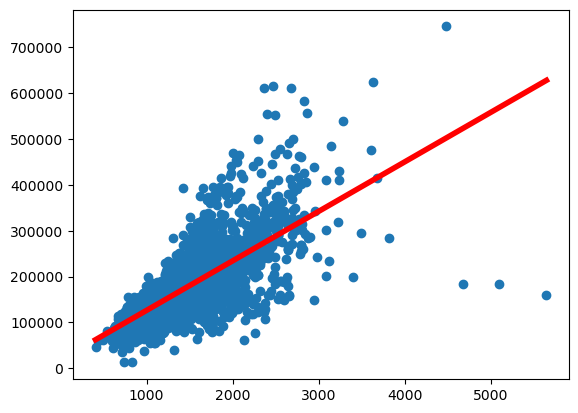

In [260]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
m = lin_reg.coef_[0]
b = lin_reg.intercept_

print(f"m: {m}, b: {b}")

x_train = X_train.iloc[:,0] # back into 1D for plotting
plt.scatter(x_train, y_train)

plt.plot([x_train.min(), x_train.max()], 
         [m * x_train.min() + b, m * x_train.max() + b], c="red", lw=4)

plt.show()

In [261]:
x_unseen = X_test.iloc[0,0]
y_unseen = y_test.iloc[0]
y_pred = m * x_unseen + b
print(f"y_pred: {y_pred}")
print(f"y_true: {y_unseen}")
print(f"error: {y_unseen - y_pred}")

y_pred: 125302.57217001004
y_true: 155000
error: 29697.42782998996


In [262]:
y_preds = lin_reg.predict(X_test)
residuals = y_test - y_pred
print(residuals)

mae = residuals.abs().mean()
print(mae)

1431     29697.42783
752     -21302.57217
1295     -5302.57217
2229     75321.42783
734       9597.42783
            ...     
1809     55697.42783
1224     -6302.57217
2408    184787.42783
489      30697.42783
2513     13697.42783
Name: SalePrice, Length: 586, dtype: float64
66944.62974262204


## Regression Evaluation Metrics
Goal: quantify the relationship between variables x and y
Several metrics
- MAE
- Correlation ($R$)
- Coefficent of determination
  - $R^2$
  - Proportion of variation in y that is explained by our model
  - The higher the $R^2$, the stronger the relationship between our
variable(s) and y
  - This is the default scoring metric for regression in sci-kit learn

In [265]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_preds)
print(r2)
r2 = lin_reg.score(X_test, y_test)
print(r2)

0.5547446221585033
0.5547446221585033
